# | Import Libraries

In [ ]:
import pandas as pd

# | Load & Preview Data

In [ ]:
url = "https://drive.google.com/uc?id=1Syb0STcuOHGRR8Lpmp6b6BTZlBDFhiSn"
df = pd.read_csv(url)

## Identifikasi Dataset

In [ ]:
df.sample(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Prediksi_Waktu
2777,2778,L49957,L,300.1,309.4,1464,41.7,30,0,No Failure,21.1
9902,9903,H39316,H,298.7,309.3,1402,45.3,190,0,No Failure,14.1
2594,2595,L49774,L,298.8,308.5,1446,37.0,11,0,No Failure,24.9
9948,9949,L57128,L,298.2,307.8,1804,25.1,108,0,No Failure,18.9
4189,4190,L51369,L,302.4,310.9,1560,31.8,172,0,No Failure,14.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
 10  Prediksi_Waktu           10000 non-null  float64
dtypes: float64(4), int64(4), object(3)
memory usage: 859.5+ KB


In [ ]:
df.describe(include='all')

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Prediksi_Waktu
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN,17.73745
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN,4.57745
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN,1.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN,15.20000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN,18.10000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN,20.82500


# | Exploratory Data Analysis

## Identifikasi *Missing Value*

In [ ]:
# Mengidentifikasi data yang hilang
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


## Identifikasi Dupikat

In [ ]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()

print(f"Baris duplikat: {duplicates.sum()}")
print(df[duplicates])

Baris duplikat: 0
Empty DataFrame
Columns: [UDI, Product ID, Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], Tool wear [min], Target, Failure Type, Prediksi_Waktu]
Index: []


## Distribusi dan Visualisasi Kolom 'Target'

Jumlah setiap kategori pada kolom Target:
Target
0    9661
1     339
Name: count, dtype: int64


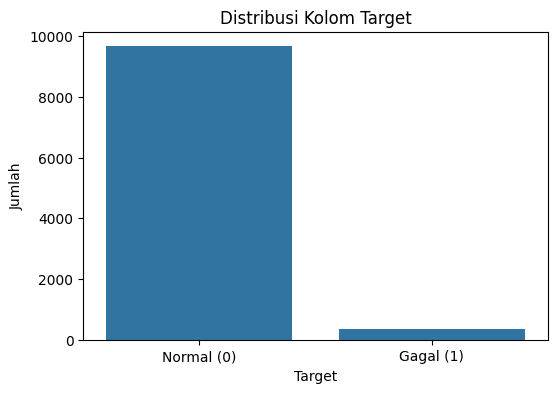

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah setiap kategori pada kolom Target
target_counts = df['Target'].value_counts()

print("Jumlah setiap kategori pada kolom Target:")
print(target_counts)

# Visualisasi distribusi kolom Target
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df)
plt.title('Distribusi Kolom Target')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Normal (0)', 'Gagal (1)']) # Memberi label pada sumbu x
plt.show()

## Distribusi dan Visualisasi Kolom 'Failure Type'

,Failure Type,Jumlah
0,No Failure,9652
1,Heat Dissipation Failure,112
2,Power Failure,95
3,Overstrain Failure,78
4,Tool Wear Failure,45
5,Random Failures,18


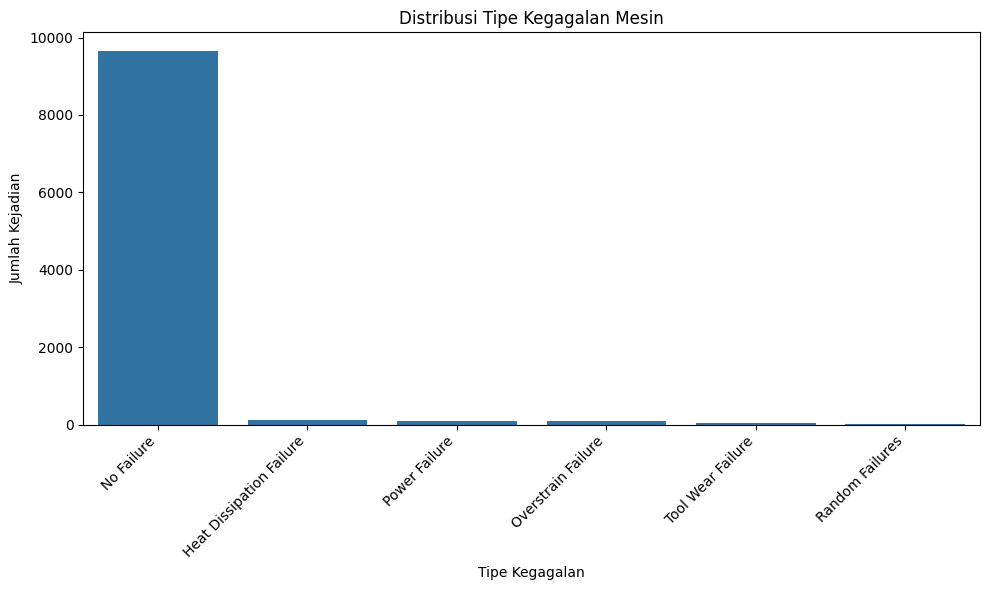

In [ ]:
failure_counts = df['Failure Type'].value_counts().reset_index()
failure_counts.columns = ['Failure Type', 'Jumlah']
display(failure_counts)
print()

import matplotlib.pyplot as plt
import seaborn as sns

# Buat bar plot untuk distribusi 'Failure Type'
plt.figure(figsize=(10, 6))
sns.barplot(x='Failure Type', y='Jumlah', data=failure_counts)
plt.title('Distribusi Tipe Kegagalan Mesin')
plt.xlabel('Tipe Kegagalan')
plt.ylabel('Jumlah Kejadian')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [ ]:
df.describe(include='all')

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Prediksi_Waktu
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.00000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure,NaN
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652,NaN
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN,17.73745
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN,4.57745
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN,1.00000
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN,15.20000
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN,18.10000
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN,20.82500




---



---



# | Encoding Strategy

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Encoding plan
# Type -> Label Encoding (karena ordinal: L, M, H)
# Failure Type -> One-Hot Encoding (karena nominal, no hierarchy)

label_encoder = LabelEncoder()
df['Type_encoded'] = label_encoder.fit_transform(df['Type'])

# One-Hot untuk Failure Type
failure_dummies = pd.get_dummies(df['Failure Type'], prefix='Failure')
df = pd.concat([df, failure_dummies], axis=1)

# | Three Models Strategy

## Model 1: Binary Classification (Target)

### Hyperparameter Tuning

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV, train_test_split
# from sklearn.metrics import classification_report, roc_auc_score
# from sklearn.utils.class_weight import compute_sample_weight

# # Features & Target
# X_binary = df[['Type_encoded', 'Air temperature [K]', 'Process temperature [K]',
#                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].copy()

# # Rename columns to remove special characters that XGBoost doesn't like
# X_binary.rename(columns={
#     'Air temperature [K]': 'Air_temperature_K',
#     'Process temperature [K]': 'Process_temperature_K',
#     'Rotational speed [rpm]': 'Rotational_speed_rpm',
#     'Torque [Nm]': 'Torque_Nm',
#     'Tool wear [min]': 'Tool_wear_min'
# }, inplace=True)

# y_binary = df['Target']

# # === Split ===
# X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
#     X_binary, y_binary, test_size=0.2, random_state=42
# )

# # === Class weight biar kelas 1 lebih diperhatiin ===
# sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_b)

# # === Model base ===
# model_xgb = XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     random_state=42,
#     tree_method='hist'  # lebih cepat
# )

# # === Parameter grid ===
# param_dist = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
#     'min_child_weight': [1, 3, 5],
#     'gamma': [0, 1, 3],
#     'scale_pos_weight': [5, 10, 20, 30]  # **ini paling krusial** untuk recall
# }

# # === Random Search ===
# random_search = RandomizedSearchCV(
#     estimator=model_xgb,
#     param_distributions=param_dist,
#     n_iter=20,                # bisa naikin jadi 50 kalau mau lebih optimal
#     scoring='recall',         # FOKUS recall kelas positif
#     cv=3,
#     verbose=1,
#     random_state=42,
#     n_jobs=-1
# )

# random_search.fit(X_train_b, y_train_b, sample_weight=sample_weights)

# print("Best Params:", random_search.best_params_)
"""
Best Params: {'subsample': 1.0, 'scale_pos_weight': 30,
 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 3, 'colsample_bytree': 0.8}
"""

"\nBest Params: {'subsample': 1.0, 'scale_pos_weight': 30,\n 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 3, 'colsample_bytree': 0.8}\n"

In [ ]:
# Features & Target
X_binary = df[['Type_encoded', 'Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']].copy()

# Rename columns to remove special characters that XGBoost doesn't like
X_binary.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
}, inplace=True)

y_binary = df['Target']

# XGBoost Classifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

model_binary = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,

    # --- Best Params dari tuning ---
    subsample=1.0,
    scale_pos_weight=30,
    n_estimators=100,
    min_child_weight=5,
    max_depth=5,
    learning_rate=0.01,
    gamma=3,
    colsample_bytree=0.8,
    tree_method='hist'
)
model_binary.fit(X_train_b, y_train_b)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## Model 2: Multi-class Classification (Failure Type)

In [ ]:
# Features & Target
X_multi = X_binary  # Same features

# Encode y_multi using LabelEncoder
from sklearn.preprocessing import LabelEncoder
label_encoder_multi = LabelEncoder()
y_multi = label_encoder_multi.fit_transform(df['Failure Type'])  # Original failure type labels

# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_m_smote, y_train_m_smote = smote.fit_resample(X_train_m, y_train_m)

model_multi = XGBClassifier(random_state=42)
model_multi.fit(X_train_m_smote, y_train_m_smote)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Model 3: Regression (Prediction Time)

In [ ]:
# Features & Target
X_reg = X_binary  # Same features
y_reg = df['Prediksi_Waktu']  # Continuous variable

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

from xgboost import XGBRegressor
model_regression = XGBRegressor(random_state=42)
model_regression.fit(X_train_r, y_train_r)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)



---



# | Evaluation Metrics

## Untuk Model 1 (Binary):

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

y_pred_binary = model_binary.predict(X_test_b)
print("Binary Classification Report:")
print(classification_report(y_test_b, y_pred_binary))
print(f"ROC-AUC: {roc_auc_score(y_test_b, model_binary.predict_proba(X_test_b)[:, 1]):.4f}")

Binary Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1939
           1       0.24      0.93      0.38        61

    accuracy                           0.91      2000
   macro avg       0.62      0.92      0.66      2000
weighted avg       0.97      0.91      0.93      2000

ROC-AUC: 0.9649


## Untuk Model 2 (Multi-class):

Multi-class Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.99      0.97      0.98      1935
           2       0.56      0.77      0.65        13
           3       0.67      0.80      0.73        20
           4       0.00      0.00      0.00         6
           5       0.12      0.36      0.18        11

    accuracy                           0.96      2000
   macro avg       0.54      0.64      0.58      2000
weighted avg       0.98      0.96      0.97      2000



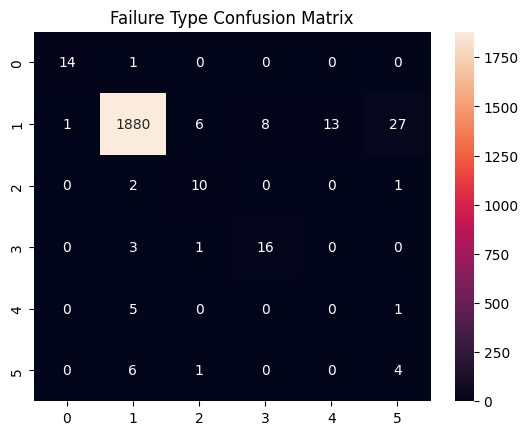

In [ ]:
y_pred_multi = model_multi.predict(X_test_m)
print("Multi-class Classification Report:")
print(classification_report(y_test_m, y_pred_multi))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_m, y_pred_multi)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Failure Type Confusion Matrix')
plt.show()

## Untuk Model 3 (Regression):

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_reg = model_regression.predict(X_test_r)
print("Regression Metrics:")
print(f"MAE: {mean_absolute_error(y_test_r, y_pred_reg):.4f}")
print(f"MSE: {mean_squared_error(y_test_r, y_pred_reg):.4f}")
print(f"R²: {r2_score(y_test_r, y_pred_reg):.4f}")

Regression Metrics:
MAE: 1.9218
MSE: 6.7663
R²: 0.6840


# | Final Pipeline Structure

In [ ]:
# Complete modeling pipeline
def build_models(df):
    # Preprocessing
    df['Type_encoded'] = LabelEncoder().fit_transform(df['Type'])
    failure_dummies = pd.get_dummies(df['Failure Type'], prefix='Failure')
    df = pd.concat([df, failure_dummies], axis=1)

    # Feature set
    features = ['Type_encoded', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
    X = df[features]

    # Three models
    models = {
        'binary_failure': (XGBClassifier(), df['Target']),
        'failure_type': (XGBClassifier(), df['Failure Type']),
        'prediction_time': (XGBRegressor(), df['Prediksi_Waktu'])
    }

    return models, X

# | Setup FastAPI & Save Models

> ini masih dalam percobaan aku untuk api nya


nanti mungkin seperti ini:<br>
predictive-maintenance-api/<br>
├── main.py                 (**FastAPI server**)<br>
├── requirements.txt        (**Dependencies**)<br>
├── model_binary.pkl       (**Saved models**)<br>
├── model_multi.pkl<br>
├── model_regression.pkl<br>
├── label_encoder_type.pkl<br>
└── label_encoder_failure.pkl

unlock comment ini dengan:<br>
**ctrl + A then ctrl + /**

In [ ]:
# save_models.py
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Save semua models dan preprocessing objects
def save_models_and_encoders():
    # Save models
    joblib.dump(model_binary, 'model_binary.pkl')
    joblib.dump(model_multi, 'model_multi.pkl')
    joblib.dump(model_regression, 'model_regression.pkl')

    # Save encoders
    joblib.dump(label_encoder, 'encoder_type.pkl')
    joblib.dump(label_encoder_multi, 'encoder_failure.pkl')

    print("✅ All models and encoders saved!")

save_models_and_encoders()

✅ All models and encoders saved!


In [ ]:
# !pip freeze > requirements.txt




---



---



# -> test dengan data mentah

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Complete modeling pipeline dengan model yang sudah ditraining
def build_and_test_models(df):
    # Preprocessing (encoding 'Type' and one-hot encoding 'Failure Type')
    # have already been performed on the global df in previous cells (e.g., HVsyWi27Wm_X).
    # This function should now only select and rename the features, assuming they are prepared.

    # The 'Type_encoded' column should already exist from previous steps.
    # No need to re-encode 'Type' or re-create failure dummies.

    # Feature set
    features = ['Type_encoded', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
    X = df[features]

    # Rename features untuk konsistensi
    X.columns = ['Type_encoded', 'Air_temperature_K', 'Process_temperature_K',
                 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

    return X

# Prepare features dari dataset asli
# Ensure the global df is used for preprocessing only once
X_processed = build_and_test_models(df.copy()) # Pass a copy to avoid unintended modifications

# TEST DENGAN DUMMY DATA
print("=== TESTING DENGAN DUMMY DATA ===")

# Buat 3 scenario dummy data
dummy_samples = [
    # Scenario 1: Mesin Sehat (No Failure)
    {
        'Type': 'M',  # akan diencode jadi 1 (asumsi L=0, M=1, H=2)
        'Air_temperature_K': 298.5,
        'Process_temperature_K': 308.2,
        'Rotational_speed_rpm': 1450,
        'Torque_Nm': 35.0,
        'Tool_wear_min': 45
    },
    # Scenario 2: Mesin Warning (Potential Failure)
    {
        'Type': 'H',
        'Air_temperature_K': 302.8,
        'Process_temperature_K': 312.5,
        'Rotational_speed_rpm': 1650,
        'Torque_Nm': 52.0,
        'Tool_wear_min': 180
    },
    # Scenario 3: Mesin Kritis (Immediate Failure Risk)
    {
        'Type': 'L',
        'Air_temperature_K': 303.5,
        'Process_temperature_K': 313.0,
        'Rotational_speed_rpm': 1750,
        'Torque_Nm': 68.0,
        'Tool_wear_min': 220
    }
]

# Convert dummy data ke DataFrame
dummy_df = pd.DataFrame(dummy_samples)

# Pastikan Type diencode dengan encoder yang sama (menggunakan label_encoder yang sudah fit)
dummy_df['Type_encoded'] = label_encoder.transform(dummy_df['Type'])

# Reorder columns sesuai dengan training data
dummy_df = dummy_df[['Type_encoded', 'Air_temperature_K', 'Process_temperature_K',
                     'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']]

print("Dummy Data untuk Testing:")
print(dummy_df)
print()

# PREDIKSI DENGAN 3 MODEL
print("=== HASIL PREDIKSI 3 MODEL UNTUK DUMMY DATA ===")

def predict_failure(model_binary, sample_df):
    # Helper function to match the original code's call signature
    binary_pred = model_binary.predict(sample_df)
    binary_proba = model_binary.predict_proba(sample_df)[:, 1]
    return binary_pred, binary_proba

for i, (idx, sample) in enumerate(dummy_df.iterrows()):
    print(f"\n{'='*50}")
    print(f"SCENARIO {i+1}:")
    print(f"{'='*50}")

    # Convert sample ke format yang sesuai untuk prediction
    sample_df = pd.DataFrame([sample])

    # 1. PREDIKSI BINARY FAILURE
    binary_pred, binary_proba_val = predict_failure(model_binary, sample_df) # Use predict_failure helper
    failure_status = "🚨 FAILURE" if binary_pred[0] == 1 else "✅ NO FAILURE"
    failure_confidence = binary_proba_val[0] * 100 # binary_proba_val contains only probability of class 1

    print(f"1. FAILURE DETECTION:")
    print(f"   Status: {failure_status}")
    print(f"   Confidence: {failure_confidence:.1f}%")

    # 2. PREDIKSI FAILURE TYPE
    failure_pred = model_multi.predict(sample_df)[0]
    failure_proba = model_multi.predict_proba(sample_df)[0]

    print(f"2. FAILURE TYPE PREDICTION:")
    # Using label_encoder_multi from global scope, which was fitted on 'Failure Type'
    predicted_failure_type_label = label_encoder_multi.inverse_transform([failure_pred])[0]
    print(f"   Type: {predicted_failure_type_label}")
    # Tampilkan 2 failure type dengan probability tertinggi
    top_2_idx = np.argsort(failure_proba)[-2:][::-1]
    for j, idx in enumerate(top_2_idx):
        print(f"   {j+1}. {label_encoder_multi.classes_[idx]}: {failure_proba[idx]*100:.1f}%")

    # 3. PREDIKSI REMAINING TIME
    time_pred = model_regression.predict(sample_df)[0]

    print(f"3. TIME TO FAILURE PREDICTION:")
    print(f"   Estimated: {time_pred:.1f} hari")

    # 4. REKOMENDASI MAINTENANCE
    print(f"4. MAINTENANCE RECOMMENDATION:")
    if binary_pred[0] == 1:
        if time_pred <= 7:
            print(f"   🚨 URGENT: Schedule maintenance immediately!")
            print(f"   ⚠️  Potential issue: {predicted_failure_type_label}")
        elif time_pred <= 14:
            print(f"   ⚠️  WARNING: Plan maintenance within {time_pred:.0f} days")
            print(f"   🔧 Check: {predicted_failure_type_label}")
        else:
            print(f"   📅 MONITOR: Maintenance needed in {time_pred:.0f} days")
    else:
        print(f"   ✅ NORMAL: Continue routine monitoring")
        print(f"   📊 Next check recommended in {time_pred:.0f} days")

    print(f"\nParameter Mesin:")
    print(f"   Type: {dummy_samples[i]['Type']}, Tool Wear: {sample['Tool_wear_min']} min")
    print(f"   Temp: {sample['Air_temperature_K']}K, Process Temp: {sample['Process_temperature_K']}K")
    print(f"   RPM: {sample['Rotational_speed_rpm']}, Torque: {sample['Torque_Nm']}Nm")

print(f"\n{'='*50}")
print("TESTING COMPLETED! ✅")
print(f"{'='*50}")


=== TESTING DENGAN DUMMY DATA ===
Dummy Data untuk Testing:
   Type_encoded  Air_temperature_K  Process_temperature_K  \
0             2              298.5                  308.2   
1             0              302.8                  312.5   
2             1              303.5                  313.0   

   Rotational_speed_rpm  Torque_Nm  Tool_wear_min  
0                  1450       35.0             45  
1                  1650       52.0            180  
2                  1750       68.0            220  

=== HASIL PREDIKSI 3 MODEL UNTUK DUMMY DATA ===

SCENARIO 1:
1. FAILURE DETECTION:
   Status: ✅ NO FAILURE
   Confidence: 24.0%
2. FAILURE TYPE PREDICTION:
   Type: No Failure
   1. No Failure: 100.0%
   2. Power Failure: 0.0%
3. TIME TO FAILURE PREDICTION:
   Estimated: 21.8 hari
4. MAINTENANCE RECOMMENDATION:
   ✅ NORMAL: Continue routine monitoring
   📊 Next check recommended in 22 days

Parameter Mesin:
   Type: M, Tool Wear: 45.0 min
   Temp: 298.5K, Process Temp: 308.2K
   RP



---

*end of the code.*

---



In [ ]:
import requests

api_url = "https://reihann321-predictive-maintenance-api.hf.space/predict"

data = {
    "Type": "M",
    "Air_temperature_K": 298.0,
    "Process_temperature_K": 230,
    "Rotational_speed_rpm": 1500,
    "Torque_Nm": 45.0,
    "Tool_wear_min": 180
}

response = requests.post(api_url, json=data)
result = response.json()
print(f"Status: {result['prediction']['is_anomaly']}")
print(f"Status: {result['prediction']['status_label']}")
print(f"Failure Type: {result['prediction']['failure_type']}")
print(f"Time to Failure: {result['prediction']['estimated_time_to_failure']} days")

Status: False
Status: Normal
Failure Type: No Failure
Time to Failure: 15.2 days
